### Econ 196 Seminar: Quantitative Long-Run Global Economic History

# WEEK 10: "Reversals of Fortune"

Download DeLong 2025-12-27 current working github repository: <<https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https://github.com/braddelong/working_20251227&urlpath=lab/tree/working_20251227/>>

<p style="text-align: left;">
    <img src="images/2026-04-02-ajr-colonial-origins.png"
     alt="J. Bradford DeLong"
     align="left"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

<br style="clear: both;">

---
---

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

#### J. Bradford DeLong :: delong@econ.berkeley.edu brad.delong@gmail.com delong@hey.com :: +1-925-708-0467

#### <<2026-04-08-DELIVERED-EDITED-econ-196-week-10-reversals-of-fortune.ipynb>>
----

##### <<https://bcourses.berkeley.edu/courses/1551896>>
##### <<https://braddelong.substack.com/t/quantitative-long-run-global-economic>>
##### <<https://braddelong.substack.com/p/quantitative-long-run-global-economic>>

----

* Tu 1-3 Evans 560
* Th 1-3 Zoom

Berkeley nbgitpuller: <<https://chromewebstore.google.com/detail/datahub-link-generator/ijbgangngghdanhcnaliiobbiffocahf?hl=en>>

* **Acemoglu, Daron, Simon Johnson, & James Robinson**. 2001. "The Colonial Origins of Comparative Development: An Empirical Investigation". _American Economic Review_ 91:5 (Dec.), pp. 1369-1401. <<http://www.jstor.org/stable/2677930>> <<https://economics.mit.edu/sites/default/files/publications/colonial-origins-of-comparative-development.pdf>>.
* **Stachurski, John, & Thomas Sargent**. 2025. "Linear Regression in Python". _QuantEcon: Intermediate Quantitative Economics with Python_. Updated Nov 21. <<https://python.quantecon.org/ols.html>>.
* **Stachurski, John, & Thomas Sargent**. 2025. _QuantEcon: Open-Source Code for Economic Modelling_. Chow Institute, Xiamen University: Xiamen, Fujian, China. <<https://quantecon.org/>>.

<br style="clear: both;">

---
---

# Econ 196 Seminar: Quantitative Long-Run Global Economic History

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

* WEEK 1: Jan 20: Introduction & human population
* WEEK 2: Jan 27: Productivity levels & technologies
* WEEK 3: Feb 3: Human evolution, effective population size, & high patriarchy.
* WEEK 4: Feb 10: Poor agrarian-age Malthusian societies
* WEEK 5: Feb 17: Societies of domination: land & seaborne agrarian-age empires.
* Feb 24: —INFLUENZA—
* WEEK 6: Mar 3: The post-1500 imperial-commercial age
* WEEK 7: Mar 10: Projector down: readings discussion
* WEEK 8: Mar 17: 1875 as the major hinge of human history
* WEEK 9: Mar 31: 
* WEEK 10: Apr 7: "Reversals of fortune" <- **WHERE WE ARE**
* The development of underdevelopment; The British industrial revolution; the post-1870 growth explosion; quantifying the prosperity hockey stick; 1775-1875 in the "Dover Circle" 
* WEEK 11: Apr 14: The current spread of wealth across nations, & prospects for further growth acceleration (or deceleration)
* WEEK 12: Apr 21: Schumpeterian unbalanced growth and political economy; the Fermi paradox; & the future of humanity
* WEEK 13: Apr 28: NO CLASS (Hicks Lecture)
* WEEK 14: May 5: Summing UP…

<br style="clear: both;">

---
---

## Source

This is a stripped-down (in the quantitative programming) and a beefed-up in the historical-interpretive) version of a notebook written by:

* **Stachurski, John, & Thomas Sargent**. 2025. "Linear Regression in Python". QuantEcon: Intermediate Quantitative Economics with Python. Updated Nov 21. <<https://python.quantecon.org/ols.html>>.

In [1]:
# initialization...

# set up the computing environment: ensure that graphs
# appear inline in the notebook & not in extra windows:

%matplotlib inline 

# import standard libraries...

import numpy as np  
import pandas as pd  
import matplotlib as mpl  
import matplotlib.pyplot as plt  

# import extra statistical libraries

# !pip install linearmodels <--THIS COMMAND NO LONGER NEEDED FOR DeLONG'S MAIN WORK THREAD

import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import linearmodels
from linearmodels.iv import IV2SLS

In [2]:
# maybe we will want to have our overview of human economic history handy...

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

human_history_df

,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index,ln_population,ln_income,ln_tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829,-4.605170,7.313220,-6.303747
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.000000,0.000106,2.649159,0.025872,0.693147,7.313220,-3.654588
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.000000,0.000008,2.851891,0.031687,1.098612,7.313220,-3.451856
3,-13000,4.00,1500.0,6000.0,10000.0,0.000029,0.000000,0.000014,2.995732,0.036589,1.386294,7.313220,-3.308015
4,-8000,5.00,1500.0,7500.0,5000.0,0.000045,0.000000,0.000022,3.107304,0.040907,1.609438,7.313220,-3.196443
5,-5000,19.00,1100.0,20900.0,3000.0,0.000445,-0.000103,0.000119,3.464650,0.058478,2.944439,7.003065,-2.839097
6,-3000,45.00,1100.0,49500.0,2000.0,0.000431,0.000000,0.000216,3.895761,0.089996,3.806662,7.003065,-2.407986
7,-1500,91.00,1100.0,100100.0,1500.0,0.000469,0.000000,0.000235,4.247860,0.127979,4.510860,7.003065,-2.055887
8,-600,150.00,1100.0,165000.0,900.0,0.000555,0.000000,0.000278,4.497748,0.164310,5.010635,7.003065,-1.805999
9,200,260.00,1100.0,286000.0,800.0,0.000688,0.000000,0.000344,4.772771,0.216324,5.560682,7.003065,-1.530976


## Reversals of Fortune

The reference is:

> "The Colonial Origins of Comparative Development: An Empirical Investigation" 
Authors: Daron Acemoglu, Simon Johnson, James A. RobinsonSource: American Economic Review, Vol. 91, No. 5 (Dec., 2001), pp. 1369-1401
Published by: American Economic Association
Stable URL: <<http://www.jstor.org/stable/2677930>>  
Or: <<https://economics.mit.edu/sites/default/files/publications/colonial-origins-of-comparative-development.pdf>>

---
---

After 1775 with the coming of the British industrial revolution century, and then much more so after the 1875 start of the Modern Economic Growth Era, the world not only gets much much richer but it also becomes vastly more unequal. There is a gonzo rise in the divergence of the destinies of different national and cultural technologies. Moreover, the big empires and the most prosperous high civilizations of the later agrarian age are not the principal beneficiaries of everything that makes and redistributes prosperity in the quarter-millennium after 1775. (_Cf._ **Allen, Robert**. 2011. "5. Five Great Empires", in _Global Economic History: A Very Short Introduction_. Oxford: Oxford University Press. <<https://archive.org/details/globaleconomichi0000alle>>.)

Why? 

Well, one line of inquiry begins by noting that we observe a very strong correlation between what we might as well call *quality of governance* and prosperity. 

But is governance quality cause or consequence? 

**Daron Acemoglu, Simon Johnson, & James Robinson**, writing in 2000, conclude that _governance quality_ is a lot of the cause.

In their view, whether a country has good governance—that encourages economic growth, encourages investment through protecting property rights, and is relatively uncorrupt—hinges on its history path and on luck. Did it develop institutions that were good for growth, both as a result of the push and pull of politically powerful actors and because of far-sighted decisions by statesmen and stateswomen? Or did it not not?

To understand the argument, let's download the data and take a look at the basic scatter of properity and "governance". The computer plots the quality of governance as estimated by Political Risk Services on the horizontal axis, and the logarithm of real income per capita in the country in 1995 on the vertical axis:

In [3]:
# download the ajr data & look at the basic scatter:
#
# 'governancequality' is as perceived over 1985-1995
# by the PRS Group <https://www.prsgroup.com>
#
# 'logincome' is year-1995 real income per capita
#
# start by reading in the AJR data from the internet:

ajr_df = pd.read_csv('data/ajr-2020.csv')

ajr_df.head()

,shortid,europeanancestry1900,excolony,governancequality,logincome,logsettlermortality,loghjypl,basesample
0,AFG,0.000000,1.0,NaN,NaN,4.540098,NaN,NaN
1,AGO,8.000000,1.0,5.363636,7.770645,5.634789,-3.411248,1.0
2,ARE,0.000000,1.0,7.181818,9.804219,NaN,NaN,NaN
3,ARG,60.000004,1.0,6.386364,9.133459,4.232656,-0.872274,1.0
4,ARM,0.000000,0.0,NaN,7.682482,NaN,NaN,NaN


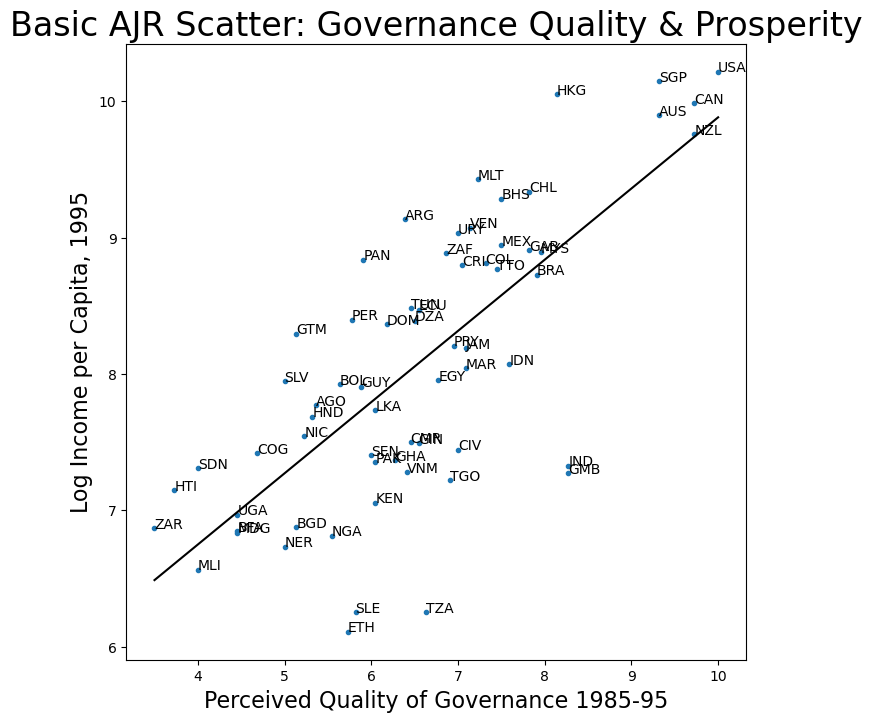

In [4]:
# drop missing observations:

ajr_df = ajr_df.dropna(subset=['logincome', 'governancequality'])

# restrict our analysis to the AJR "base" sample:

ajr_df = ajr_df[ajr_df['basesample'] == 1]

# tell python to expect figures to come 
# by initializing the python objects to hold the figures...

fig, ax = plt.subplots(figsize=(8,8)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(ajr_df['governancequality'], ajr_df['logincome'], marker='.')

# now loop through the data[points in the figure, annotating each
# data point with a three letter code ('Threeletterabbrevation') identifying the 
# country refered to:

for i, txt in enumerate(ajr_df['shortid']):
    ax.annotate(txt, (ajr_df['governancequality'].iloc[i], ajr_df['logincome'].iloc[i]))
    

# draw a straight least-squares fit line through the data

ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governancequality'], ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

# set the figure labels, and show the figure:

ax.set_xlabel('Perceived Quality of Governance 1985-95', size=16)
ax.set_ylabel('Log Income per Capita, 1995', size=16)
ax.set_title('Basic AJR Scatter: Governance Quality & Prosperity', size=24)
plt.show()

The computer has plotted the points with perceived governance quality over 1985-1995 on the horizontal and the log of income per capita in 1995 on the vertical axis. It has also calculated and drawn a line. This line corresponds to an equation. Let's let Y be our symbol for income and G be our symbol for governance quality. Then the line the computer has drawn is the least-squares fit line for the equation:

>$ log(Y) =  \hat{\beta}_{0} + \hat{\beta}_{G}(G) $

What is this "least-squares fit line?" 

(For a more comprehensive introduction: **Stachurski, John, & Thomas Sargent**. 2025. "Linear Regression in Python". _QuantEcon: Intermediate Quantitative Economics with Python_. Updated Nov 21. <<https://python.quantecon.org/ols.html>>; & more generally **Stachurski, John, & Thomas Sargent**. 2025. _QuantEcon: Open-Source Code for Economic Modelling_. Chow Institute, Xiamen University: Xiamen, Fujian, China. <<https://quantecon.org/>>.)

The least-squares fit line is the line for which, when you take the vertical distances from each of the data points to the line, square those distances, and then add them up, that sum is lowest. 

In order to draw the line, the computer has to choose two parameters. The first is $ \hat{\beta}_{0} $, a "constant" term: changing it shifts the line up and down, and when it is equal to zero the line must go through the (0,0) point on the graph. The second is $ \hat{\beta}_{G} $, the amount by which a one-unit increase in the variable on the x-axis raises the value of the variable on the y-axis: changing it tilts the line.

Drawing this least-squares fit line is a good thing to do if the data-generating process is composed of (a) a linear straight-line relationship between the x-axis and the y-axis variables, plus (b) an extra ("disturbance") term raising or lowering the y-axis value by a random amount that has a _normal distribution_. Such a normal ditribution means "thin tails": that is, the chance that an observation will be very far from the underlying relationship between the x-axis and y-axis variables is very small, and that chance decreases very very rapidly indeed as you get further away.

We can get the computer to print out a bunch of information about this least-squares fit line—information that should be familiar to you from statistics:

In [5]:
# information about the least-squares fit.

ajr_df['constant'] = 1

print('REGRESSION OF PROSPERITY ON GOVERNANCE QUALITY')

ols_result = sm.OLS(endog=ajr_df['logincome'],
                    exog=ajr_df[['constant', 'governancequality']],
                    missing='drop').fit()

print(ols_result.summary())

print("======")

print(f"OLS residual variance (σ²_ε): {ols_result.mse_resid:.4f}")
print(f"Var(Y): {ajr_df['logincome'].var():.4f}")
print(f"Var(G): {ajr_df['governancequality'].var():.4f}")

REGRESSION OF PROSPERITY ON GOVERNANCE QUALITY
                            OLS Regression Results                            
Dep. Variable:              logincome   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     72.82
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.72e-12
Time:                        14:31:42   Log-Likelihood:                -68.168
No. Observations:                  64   AIC:                             140.3
Df Residuals:                      62   BIC:                             144.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In issuing that last command:

* "sm" is the "statsmodels" package applications programming interface that we loaded earlier;
* "OLS" means that we are carrying out a least-squares fit in the "ordinary" O (as opposed to, say, a "two stage" 2S) analysis;
* "endog = ajr_df['logincome']" says that the thing we are trying to predict, analyze, and understand is the "logincome" variable in the "ajr_df" dataframe;
* "exog = ajr_df['constant', 'governancequality']" says that we are assuming that logincome is determined by the "governancequality" quality-of-governance variable and the constant term (so that logincome does not have to be zero when avgexpr is zero) in the "ajr_df" dataframe;
* "missing = drop" means that we drop from the analysis any observations—dataframe rows—in which some values of the data are missing;
* "fit" means that we want to look at how well the least-squares line does at "fitting" the data;
* "summary" means that we only want to look at the summary table;
* and "print" means that we want the analysis printed out to the screen so that we can look at it.

For our purposes, there are four very important numbers to look at in what the computer has given us. 

Look, first, at the 0.540 labeled "R-squared" in the top-right. 

This tells us what proportion of the variation in the variable we are trying to understand—log(Y), the log of real income per capita in 1995—we could fit to our model from knowing the least-squares line and knowing the values of our predictor variables—a constant, and the quality of governance G. 52.2% of the variation in log(Y) could be predicted or accounted for by the variation in governance quality G.

Look, second at the 0.644 on the right, just above the third line of equals signs "...======". 

It tells us that, if 

* this regression analysis is correctly specified (i.e., quality of governance as we have estimated it is the only systematic determinant of log income per capita), 
* the random disturbances to log income per capita have nothing to do with each other (are "independent"),
* these disturbances have a normal distribution ("thin tales"),
* and the data were generated starting from values of governance quality G by the equation: $ log(Y)=  \beta_{0} + \beta_{G}(G) + \epsilon $

then there is only a 2.5% chance that our procedure will generate a top limit that is lower than the "true" $ \beta_{G} $ that generated the data, and our procedure generated a top limit of 0.644.

Why this elliptical way of expressing it? Because the normal way ("there is only a 2.5% chance that the true $ \beta $ > 0.644") implies that you have your interval, and that $ \beta_{G} $ is a random variable that can be in or out if it. But actualy $ \beta $ is whatever it is, and is not affected by what the data turned out to be. The thing that is random is the interval. 0.644 is a realization random variable that could have been high and could have been low. There was only a 2.5% chance that it would be higher than the true $ \beta_{G} $. But now that it has been calculated and realized, it is either higher than the true $ \beta $ or it is not—but since you do not know the true $ \beta_{G} $, you do not know which is the case.)

Look, third, at the 0.400 just to the left of the 0.644. It tells us that if:

* this regression analysis is correctly specified (i.e., quality of governance as we have estimated it is the only systematic determinant of log income per capita), 
* the random disturbances to log income per capita have nothing to do with each other (are "independent"),
* these disturbances have a normal distribution ("thin tales"),
* and the data were generated starting from values of governance quality G by the equation: $ log(Y)=  \beta_{0} + \beta_{G}(G) + \epsilon $

then there is only a 2.5% chance that our procedure will generate a bottom limit that is higher than the "true" $ \beta_{G} $ that generated the data, and our procedure generated a bottom limit of 0.400.

We call the range [0.400, 0.644] the *95% confidence interval*. And we say that it is statistically unlikely that this randomly generated confidence interval that is a function of how pure chance generated the disturbance causes of real income per capita lies entirely outside of the true $ \beta $. Whenever zero is not included in the confidence interval, people tend to say that that fact is "statistically significant". But it is better to avoid saying that, as it tends to lead to very fuzzy and misleading thinking.

And the 0.5221, the first number in that row, is the average of the top and bottom limits, and we take that to be our "point estimate" of the association between governance quality G and prosperity log(Y).

Now, just for the moment, let us suppose that the values of the equation:

>$ log(Y) =  \hat{\beta}_{0} + \hat{\beta}_{G}(G) $

that our statistical analysis has estimated are the true values, and they are as given by the first numbers in the lines that start with "constant" and "governancequality":

>$ \hat{\beta}_{0} = 4.6604 $    
$ \hat{\beta}_{G} = 0.5221 $

Thus if governance quality were zero, we would expect the log of income per capita to be 4.66. And we would expect every one-unit increase in governance quality to carry with it an 0.522 increase in the log of income per capita.

What does such an equation mean?

First, we do not get governance quality scores less than 4. What is the annual real income per capita for a country with a governance quality score of 4, given our two parameters 4.66 and 0.5221?:

In [6]:
# the annual income per capita level predicted by our equation
# for a country with a governance quality G equal to 4

y_govqualis4 = np.exp(4.6604 + 0.5221*4) 

print("$",y_govqualis4, "per year   is the annual income per capita level for a governance-quality index of 4")

$ 853.0345066875342 per year   is the annual income per capita level for a governance-quality index of 4


That is an income not that much more than subsistence... 

Since the y variable is a logarithm, recognize that each 0.522 arithmetic increase in the log as governance quality increases unit by unit is an equal multiplicative factor applied to income per capita. Let's calculate what that multiplicative factor is:

In [7]:
# calculate by what factor expected income is multiplied when 
# governance quality is increased by one unit:

oneunitincomemult = np.exp(0.522) 

print("Increasing governance quality by one multiplies expected income by a factor of:", oneunitincomemult)

Increasing governance quality by one multiplies expected income by a factor of: 1.6853950712974088


These effects multiply. BY the time we reach a pair of countries whose risk of appropriation scores differ by 6, the fitted relationship associates that with a difference in real per capita income of a factor of 23: the richer country is 23 times richer than the poorer one, according to the line of best fit. And that is the difference that is associated with the difference between a governance-quality index of 4 and a governance-quality index of 10, between a Haiti and a New Zealand.

---
---

## Directions of Causation...

But which way does cause run? Is governance quality the cause, and prosperity the effect? Or is it prosperity—or the other factors that truly drive prosperity—that is the cause, and governance quality that is the effect? What happens if what you conduct an analysis, but what you think is cause is really effect?

Let us try to think through this issues. Let us, for the moment, assume that the level of prosperity Y is indeed determined by good governanCe G and by other, random, disturbance factors that we gather together and add up into the random variable which we call $ \epsilon $. What is this random variable $ \epsilon $ ? It is a thing that varies, randomly—that we cannot predict from inside the system. So we write:

$ Y = \beta G + \epsilon $    

And let us also assume, again for the moment, that prosperity Y causes high governance quality G—that prosperity leads to a society in which people have the resources and the voice and the power to demand good governance:

$ G = \gamma( Y +  \nu ) $

Where here the other causes of governance quality G than prosperity Y are gathered into another random variable which we call $ \nu $ which, again, varies, randomly, and which we cannot predict from inside the system. 

Then if we solve for what Y and G are as functions of our random variables $ \epsilon $ and $ \nu $, we get:

$ Y = \frac{1}{1 - \beta\gamma}\epsilon + \frac{\beta\gamma}{1 - \beta\gamma} \nu $    
$ G = \frac{\gamma}{1 - \beta\gamma}\epsilon + \frac{\gamma}{1 - \beta\gamma} \nu  $

Now we can start analyzing what we would expect a linear regression analysis like that of 8.3 to report about the relationship between G and Y. 

### B. How a Regression Analysis Calculates $ \beta $...

We can think of how the linear regression analysis calculates $ \beta $ this way:

1. The analysis starts as multiplying G by Y and then taking its "expectation" (we have to take expectations, because both G and Y are determined by these $ \epsilon $ and $ \nu $ objects that are varying randomly, so all we can say is what we expect them to be).
2. The analysis continues by multiply G by multiplying itself and take its expectation
3. The analysis then divides the first by the second: 

In doing this calculation, the normal rules of arithmetic apply, with some added weirdness. There are five points of added weirdness:

1. We write $ \sigma^2_{G} $ for our expectation of G multiplied by itself—but instead of saying "what we expect the variation in Y times itself to be", we say that this is the *variance* of G.

2. We write $ \sigma_{YG} $ for our expectation of G multiplied by Y—but instead of saying "what we expect the variation in G times Y to be", we say that this is the *covariance* of G and Y.

3. We, similarly to (1), write $ \sigma^2_{\epsilon} $ for our expectation of $ \epsilon $ multiplied by itself—but instead of saying "what we expect the variation in $ \epsilon $ times itself to be", we say that this is the *variance* of $ \epsilon $.

4. We, similarly to (1), write $ \sigma^2_{\nu} $ for our expectation of $ \nu $ multiplied by itself—but instead of saying "what we expect the variation in $ \nu $ times itself to be", we say that this is the *variance* of $ \nu $.

5. Wherever we are taking the expectation of something that has an $ \epsilon $ multiplied by a $ \nu $ in it, we set it equal to zero: $ \sigma_{\epsilon\nu} = 0 $

Applying these rules—and the normal rules of arithmetic—we can then unpack what is in Y and G to calculate:

First we find that we expect: $ \sigma_{YG} = \left[ \gamma \sigma^2_{\epsilon} + \beta \gamma^2 \sigma^2_{\nu} \right] \left[\frac{1}{1-\beta\gamma}  \right]^2 $

Second we find that we expect: $ \sigma_{GG} = \left[ \gamma^2 \sigma^2_{\epsilon} + \gamma^2 \sigma^2_{\nu} \right] \left[\frac{1}{1-\beta\gamma}  \right]^2 $

Thus, third: $ \frac{ \sigma_{YG}}{\sigma_{GG}} =  
\frac {\gamma \sigma^2_{\epsilon} + \beta \gamma^2 \sigma^2_{\nu}}   
{\gamma^2 \sigma^2_{\epsilon} + \gamma^2 \sigma^2_{\nu}} $

This last is what we expect the linear regression analysis to produce: we expect the $ \hat{\beta} $ produced by the regression analysis to be:

>$ \hat{\beta} = \frac{ \sigma_{YG}}{\sigma_{GG}} $

It is convenient define a quantity that is the ratio of the two kinds of random variation in the model: $ \rho = \frac{\sigma^2_{\nu}} {\sigma^2_{\epsilon}} $. 

Then: $  \hat{\beta} = \frac{\sigma_{YG}}{\sigma_{GG}} = 
 \left( \frac{ \rho}{1 + \rho} \right) \beta +  \left( \frac{1 }{1  + \rho} \right) \frac{1}{\gamma}
$

The OLS regression coefficient $ \hat{\beta} $ is thus expected to be a weighted average of:

1. the true $ \beta $ causal relationship between G and Y on the one hand, and 
2. the $ \frac{1}{\gamma} $ reverse-causation confounding term back from Y to G on the other. 

The weights in this weighted-average calculation are the relative variations $ \rho /(1 + \rho) $ and $ 1/(1 + \rho) $: how much variation there is in the other things in the past or present that independently affect G, $ \nu $, relative to how much variation there is the other things $ \epsilon $ besides governance quality that determine prosperity. When there is little variation in $ \nu $ relative to $ \epsilon$—when little affects governance quality besides prosperity—then the estimated regression coefficient is close to (1/𝛾), and has little to do with any causal relationship running from governance quality to prosperity. When there is little variation in $ \epsilon $ relative to $ \nu $—when little determines prosperity except for governance quality—the estimated coeffient is close to the strength of the causal relationship between governance quality and prosperity.

Alternatively we could write:

$ \beta = \hat{\beta} + \frac{1}{\rho}\left( \hat{\beta} - \frac{1}{\gamma} \right) $

Correct $ \hat{\beta} $ by adding (1/𝜌) times the difference between $ \hat{\beta} $ and 1/𝛾 in order to get the true causal-relationship 𝛽.

&nbsp;

### What $\hat{\beta} = 0.522 $  Tells Us...

We do not know either $ \rho $—the relative variability of the other factors that are determining G or Y—or $ \gamma $—the strength of the causal forces leading good governance to be a result of prosperity. AJR worry that their impressive scatter is a result of this reverse causation.

What can we say about it?

First, if $ \gamma = 0 $—if there is no reverse causation from prosperity to governance quality—then we expect the true $ \beta = \hat{\beta} = 0.522 $. There is no problem. So let's consider only what might go wrong with our analysis when $ \gamma ≠ 1 $.

Second, we are fine either if $ | \beta - 1/\gamma | $ is small or if $ \rho $ is sufficiently large. Only when $ \rho $ is not sufficiently large and $ | \beta - 1/\gamma | $ is not small do we run into problems. And then we run into big problems. Which we do.rios—the first one with the true $ \gamma = 1 $—and see how different values of $ \rho $ lead us to expect to get different values of $ \hat{\beta} $:

One thing we might do is to look at and think about "outliers" that are off the scatter relationship.

For example: Panama, El Salvador, Guatemala, Argentina, Peru, Malta, and Hong Kong were all somewhat richer in 1995 than the standard scatter would have led us to expect. We can ask the questions: Why are they different? Is it that something interrupted the chain of transmission from prosperity to governance quality, so they wound up with worse governance quality than their prosperity should have produce? Or is it that some special benefit gave them more prosperity than their governance quality should otherwise have been able to support?

Conversely: Nigeria, Togo, Cote d'Ivoire, Vietnam, Kenya, Tanzania, Sierra Leone, the Gambia, Ethiopia, and India are all poorer in 1995 than their governance quality would have led us to anticipate. Did something good happen to governance, giving them better governance than their prosperity fundamentals would have normally generated? Or did something bad happen to their levels of income to depress it?

In this case, we are looking at historical events that disrupted normal patterns of causation. 

Another thing we might do is look at the influential observations that follow the scatter relationship. We know a great deal about the U.S., Canada, Australia, New Zealand, and Singapore. Are they prosperous because they have high-quality governance? Or do they have high-quality governance because they are prosperous? Conversely, the worst-off countries in the world in 1995 in both governance and prosperity were the Congo, the Democratic Republic of the Congo, Mali, Haiti, Sudan, Madagascar, Niger, Uganda, and Bangladesh. Were they, predominatly, poor beause they had low-quality governance? Or did they have low-quality governance predominately because they were poor?

---
---


## What Can We Say?: Instrumental-Variable Analysis

So what can we say? Recall our basic AJR scatter:

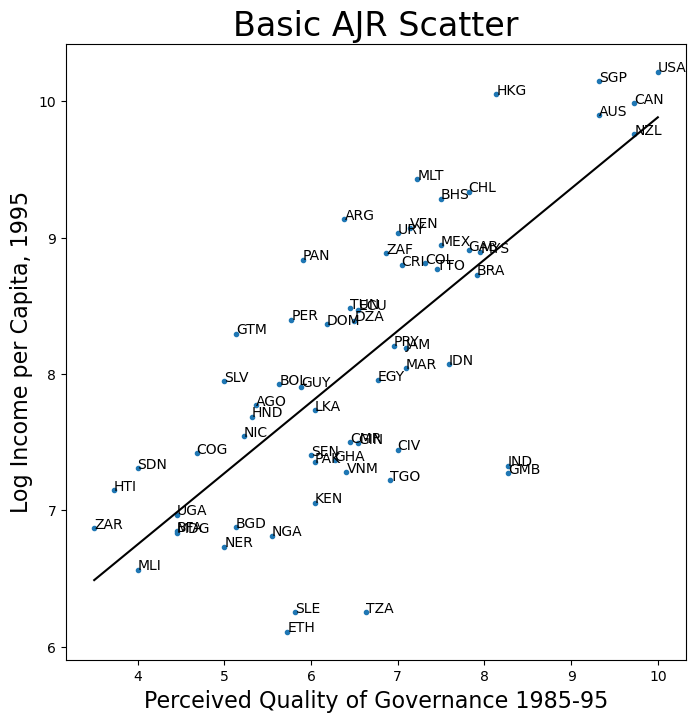

In [19]:
# governance quality & prosperity: basic scatter plot

# tell python to expect figures to come 
# by initializing the python objects to hold the figures...

fig, ax = plt.subplots(figsize=(8,8)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(ajr_df['governancequality'], ajr_df['logincome'], marker='.')

# now loop through the data[points in the figure, annotating each
# data point with a three letter code ('Threeletterabbrevation') identifying the 
# country refered to:

for i, txt in enumerate(ajr_df['shortid']):
    ax.annotate(txt, (ajr_df['governancequality'].iloc[i], ajr_df['logincome'].iloc[i]))
    

# draw a straight least-squares fit line through the data

ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governancequality'], ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

# set the figure labels, and show the figure:


ax.set_xlabel('Perceived Quality of Governance 1985-95', size=16)
ax.set_ylabel('Log Income per Capita, 1995', size=16)
ax.set_title('Basic AJR Scatter', size=24)
plt.show()

### The Benefits of an Instrument

AJR do not have strong and informed views about both the value of ɣ, the strength of the reverse-causation channel from prosperity back to high-quality governance, and of ⍴, the ratio of the variation. Hence AJR follow a different track.

Suppose that there was some other variable—let us call it C, for climate and its impact on settler mortality—that had an impact on quality of governance G, but aside from its impact on quality of governance had no other impact on or correlation with prosperity Y. Then our two equations would be :

>$ Y = \beta G + \epsilon $

>$ G = -\delta C + \gamma( Y +  \nu ) $

Now let's get the Y and the Gs out of the right-hand sides:

>$ G = -\left( \frac{\delta}{1 - \beta\gamma } \right)C + \left( \frac{\gamma}{1 - \beta\gamma } \right)( \epsilon +  \nu ) $

>$ Y = -\beta\left(\frac{ \delta}{1 - \beta \gamma}\right) C + 
    \left(\frac{\beta \gamma}{1 - \beta \gamma}\right) \nu  + \left(\frac{1}{1 - \beta \gamma}\right)\epsilon $

Now suppose we calculated what we would have expected G to be if all we had known about was C:

>$ \hat{G} = -\left(\frac{ \delta}{1 - \beta \gamma}\right) C $

And then calculated:

>$ \hat{\beta}_{IV} = \frac{\sigma_{\hat{G}Y}}{\sigma^2_{\hat{G}}} $

what would we get? 

Well, remember from our rules for doing this probability-statistical algebra:

>$ \sigma_{\hat{G}}^2 = \left( \frac{\delta}{1 - \gamma \beta} \right)^2 \sigma_C^2 $

>$ \sigma_{Y\hat{G}} = \beta \left( \frac{\delta}{1 - \gamma \beta} \right)^2 \sigma_C^2 $

>$ \hat{\beta}_{IV} = \beta $

We would find the true causal relationship from prosperity to income, uncorrupted by reverse causation. And all our problems would be gone—save for the problem of finding such an instrumental variable C.

&nbsp;

### European-Settler Mortality

Acemoglu, Johnson, and Robinson believe that they have found such a variable in the weather, or rather the climate—specifically, early European-settler mortality. They take the risk that European settlers early in the colonial era would die if they took up residence in a colony to be a _valid instrumental variable_: something that is correlated with their x-axis cause variable, governance quality, and _correlated with the y-axis effect variable, prosperity, only to the extent that governance quality causes prosperity_. 

AJR argue that settler "mortality rates were a key determinant of European settlement." Where the climate was favorable and thus settler mortality was low, Europeans settled in large numbers and established "settler colonies". And these then gave rise to pro-prosperity "developmental institutions" with high-quality governance:

>Where Europeans settled in large numbers, and life was modeled after the home country.... The settlers wanted... freedom and the ability to get rich by engaging in trade.... When the establishmentof European-like institutions did not arise naturally, the settlers were ready to fight for them against the wishes of the home country.... The settlers wanted institutions and political rights like those prevailing in England at the time. They demanded jury trials, freedom from arbitrary arrest, and electoral representation...

By contrast, where the climate was unfavorable, European colonialist powers imposed "extractive institutions":

>There were few constraints on state power in the nonsettler colonies. The colonial powers set up authoritarian and absolutist states with the purpose of solidifying their control and facilitating the extraction of resources...

These then gave rise to anti-prosperity low-quality governance:

>The control structure set up in the nonsettler colonies during the colonial era persisted.... The institutions of law and order and private property established during the early phases of colonialism in Australia, Canada, New Zealand, the United States, Hong Kong, and Singapore have formed the basis of the current-day institutions of these countries.... [And] the extractive institutions set up by the colonialists persisted long after the colonial regime ended...

Extractive institutions then make it much more likely that quality-of-governance is low now. Low-quality governance contributes to present-day poverty. And, AJR argue, there are no other alternative causal links between a favorable or unfavorable climate for settlement then to prosperity or poverty now. The only way that climate then and prosperity now are linked is through this chain of causation: from climate to institutions then, from institutions then to governance quality now, and from governance quality now to prosperity now.

&nbsp;

### AJR Claim to Estimate the Causal Relationship

Let us, for the moment, provisionally pursue AJR's line of reasoning. Suppose that these claims are true. Then we can figure out $ \hat{G} $—what we would have expected governance-quality to be from the country's settler-mortality climate—by asking the Python interpreter to calculate what the relationship line between C and G:

In [20]:
# relationship between governance quality and settler mortality

ajr_df['constant'] = 1

first_stage = sm.OLS(endog=ajr_df['governancequality'],
                     exog=ajr_df[['constant', 'logsettlermortality']],
                     missing='drop').fit()



print(first_stage.summary())

print("======")

print(f"First stage residual variance (σ²_ν): {first_stage.mse_resid:.4f}")

                            OLS Regression Results                            
Dep. Variable:      governancequality   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     22.95
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.08e-05
Time:                        14:33:31   Log-Likelihood:                -104.83
No. Observations:                  64   AIC:                             213.7
Df Residuals:                      62   BIC:                             218.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
constant                9.3414    

And then in the next code cell, use those two coefficients 9.3414 and -0.6068 to calculate what we would have expected governance quality to be if all we knew was what settler mortality had been:

In [21]:
# calculating what governance quality we would expect given settler mortality

ajr_df['governance_quality_iv'] = 9.3414 - 0.6068 * ajr_df['logsettlermortality'] 

Then we can draw the scatter diagram and the relationship line—only putting not governance quality but the portion of governance quality that is related to settler mortality on the x-axis. And then the slope of this relationship line is supposed, according to AJR, to give us the strength of the causal relationship running from governance quality to prosperity: 

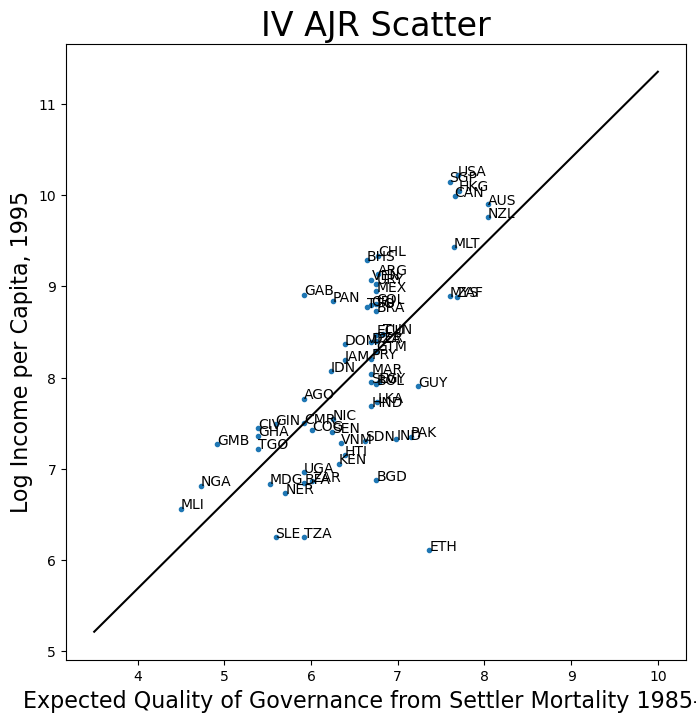

In [22]:
# draw the chart, and also draw a straight
# least-squares fit line through the data

fig, ax = plt.subplots(figsize=(8,8)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(ajr_df['governance_quality_iv'], ajr_df['logincome'], marker='.')  



# now loop through the data points in the figure, annotating each
# data point with a three letter code ('Threeletterabbrevation') identifying the 
# country refered to:

for i, txt in enumerate(ajr_df['shortid']):
    ax.annotate(txt, (ajr_df['governance_quality_iv'].iloc[i], ajr_df['logincome'].iloc[i]))
    
ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governance_quality_iv'], ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

# set the figure labels, and show the figure:

ax.set_xlabel('Expected Quality of Governance from Settler Mortality 1985-95', size=16) 
ax.set_ylabel('Log Income per Capita, 1995', size=16) 
ax.set_title('IV AJR Scatter', size=24)
plt.show()



In [23]:
results_ss = sm.OLS(
    endog=ajr_df['logincome'],
    exog=ajr_df[['constant', 'governance_quality_iv']],
    missing='drop'
).fit()

print(results_ss.summary())

                            OLS Regression Results                            
Dep. Variable:              logincome   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     56.60
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.66e-10
Time:                        14:33:41   Log-Likelihood:                -72.268
No. Observations:                  64   AIC:                             148.5
Df Residuals:                      62   BIC:                             152.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
constant                  1.91

&nbsp;

### Assessing This Instrumental-Variable AJR Estimate

We gain a lot of insight by plotting this side-by-side our original scatter:

<img src="images/ajr-ols-%26-iv.png" width="800" />

We were expecting to find out from this analysis how far the true $ \beta $ was below the originally estimated $ \hat{\beta} $: we were expecting to find a flatter line than in our original scatter, because we have purged it of the reverse causation back from prosperity to good governance. Instead, we have found—if we trust this instrumental-variables procedure—that we have a $ \hat{\beta}_{IV} = 0.9443 $, not smaller but larger than our $ \hat{\beta}_{OLS} = 0.5221 $.

What are we to make of this?

Arithmetically, it is clear what is going on. A lot of the very good institutions of rich countries are features that we would not have expected to see given that back early in the age of imperialism their settler mortality climate was not _that_ low, and a lot of the very bad institutions of poor countries are features that we would not have expected to see given that back early in the age of imperialism their settler mortality climate was not _that_ high. Thus the $ \sigma_\hat{G}^2 $ is low. And so, when we divide the correlation $ \sigma_{Y\hat{G}} $ between expected institutions and prosperity by the small $ \sigma_\hat{G}^2 $, we get a large number.

Remember that we thought our original $ \hat{\beta} $ was not trustworthy as an estimate of the true causal slope $ \beta $ because there was this $ \gamma $ reverse causation from prosperity back to governance quality in the mix. What does this instrumental-variables result tell us about the strength of this $ \gamma $ reverse causation?

Remember the relationship between the best-fit line slope from the scatter $ \hat{\beta} $ and the true $ \beta $ that tells us the strength of the causal relationship—how much raising governance-quality G by one unit raises prosperity Y:

$  \hat{\beta} - \beta =  
 \left( \frac{1 }{1  + \rho} \right) \left( \frac{1}{\gamma} - \beta \right)
$

We have our orgoinal scatter $  \hat{\beta}_{OLS} = 0.5221 $ and, if the instrumental-variables estimate is correct, $ \beta =  0.9443 $. That would then mean, if the instrumental-variables analysis is correct, that:

$  0.5221 - 0.9443 =  
 \left( \frac{1 }{1  + \rho} \right) \left( \frac{1}{\gamma} - 0.9443 \right)
$

$ -0.4222 - 0.4222\rho = - 0.9443 + \frac{1}{\gamma} $

$ 0.5221 - 0.4222\rho =  \frac{1}{\gamma} $

In the next code cell, we plot this relationship between the variance-of-disturbances ratio $ \rho $ and the effect of prosperity on governance quality $ \gamma $ for $ \rho $ varying between 0.01 and 1.23. Do so by constructing two lists, rho_series and gamma_series, that will then be plotted, with the gamma_series containing the value you calculate for $ \gamma $ for each corresponding value of $ \rho $ 

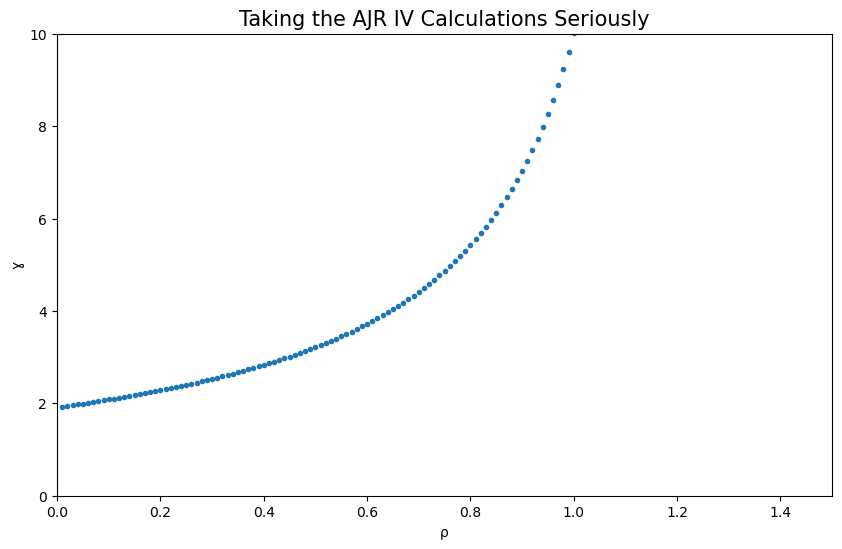

In [24]:
# relationship between variance ratio 𝜌 and causal effect of prosperity on governance quality 𝛾

beta_hat = 0.5221
beta = 0.9443
rho_series = []
gamma_series = []

for i in range(1,123):                       
    rho = i/100                              
    gamma = 1/(0.5221 - 0.4222*rho)          
    gamma_series = gamma_series + [gamma]    
    rho_series = rho_series + [rho]         
    

fig, ax = plt.subplots(figsize=(10,6)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, gamma_series, marker='.')

ax.set_xlabel('⍴', size=10)
ax.set_ylabel('ɣ', size=10)
ax.set_ylim(0, 10)
ax.set_xlim(0, 1.5)
ax.set_title('Taking the AJR IV Calculations Seriously', size=15)
plt.show()

For a variance ratio $ \rho < 1.2366 $, in order to get a best-fit line with a slope $ \hat{\beta} = 0.5223 $ in the full scatter while the true causal effect $ \beta $ of better governance on higher prosperity is $ \beta = 0.9441 $, there must be a very strong and very positive causal effect of governance-quality on prosperity: a high value of $ \gamma $.

This is a problem: A high value of $ \gamma $ means that relatively small differences in prosperity across countries set in motion social forces that lead to very large increases in quality of governance. It is plausible to point at history and political economy and argue that higher governance quality leads to more prosperity. But few (if any) historians and analysts point at history and political economy and argue that there are very strong forces leading from prosperity to higher governance quality. Some, yes—that prosperity has some impact, and that factors making for general societal competence have an impact on both. But a very strong cause-and-effect relationship? Implausible.

Things are even worse for a variance ratio greater than $ \rho > 1.2366 $. In the next code cell, we plot this relationship between the variance-of-disturbances ratio $ \rho $ and the effect of prosperity on governance quality $ \gamma $ for $ \rho $ varying between 1.3 and 10. Do so by constructing two lists, rho_series and gamma_series, that will then be plotted, with the gamma_series containing the value you calculate for $ \gamma $ for each corresponding value of $ \rho $ 

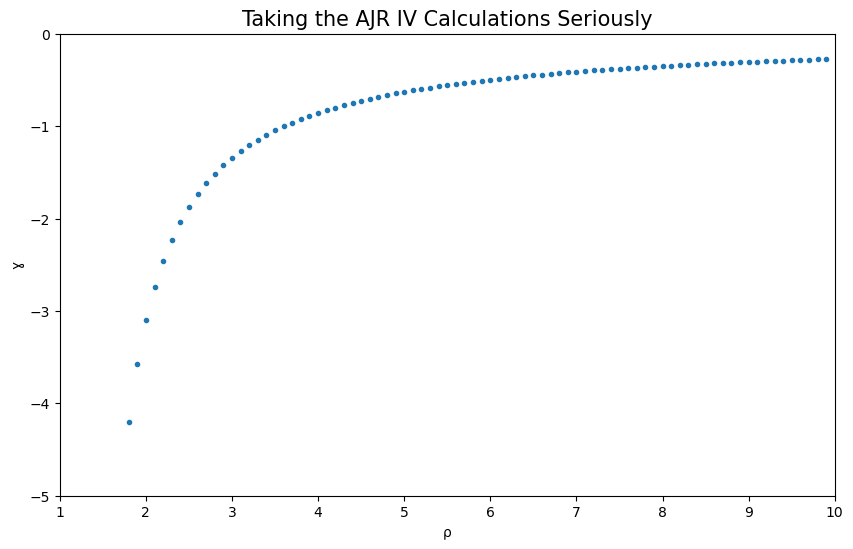

In [25]:
# relationship between variance ratio 𝜌 and causal effect of prosperity on governance quality 𝛾

beta_hat = 0.5221
beta = 0.9443
rho_series = []
gamma_series = []

for i in range(13,100):                      
    rho = i/10                               
    gamma = 1/(0.5221 - 0.4222*rho)          
    gamma_series = gamma_series + [gamma]   
    rho_series = rho_series + [rho]         
    

fig, ax = plt.subplots(figsize=(10,6)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, gamma_series, marker='.')

ax.set_xlabel('⍴', size=10)
ax.set_ylabel('ɣ', size=10)
ax.set_ylim(-5, 0)
ax.set_xlim(1, 10)
ax.set_title('Taking the AJR IV Calculations Seriously', size=15)
plt.show()

For a variance ratio greater than $ \rho > 1.2366 $, to reconcile our original scatter with its slope and the instrumental-variables analysis with its slope, we need there to be a _negative_ causal relationship between prosperity and governance-quality. A country's being richer needs to cause—or other factors that lead to a country's being richer need also to cause—the quality of governance to decline: more corruption, more inefficiency, and a greater fear of expropriation.

Now this makes no sense at all. Historically, revolutions and expropriations have not occurred in rich but in poor countries. And it seems to be trying swallow a camel to say that the other things that cause prosperity also cause low-quality government.

&nbsp;

### The Implied $ \gamma $: A Quantitative Assessment

We can make this more precise. Our residual variance estimates from the notebook give us:

* $ \hat{\sigma}^2_{\varepsilon} = 0.5087 $ (residual variance from the OLS regression of log income on governance quality)
* $ \hat{\sigma}^2_{\nu} = 1.5997 $ (residual variance from the IV first-stage regression of governance quality on log settler mortality)
* $ \hat{\beta}_{OLS} = 0.54 $, $ \beta_{IV} = 1.10 $

Our model implies:

$$
\gamma = \frac{\sigma^2_{\varepsilon}}{\hat{\beta}_{OLS}\,\sigma^2_{\varepsilon} - (\beta_{IV} - \hat{\beta}_{OLS})(\sigma^2_{\varepsilon} + \sigma^2_{\nu})}
$$

Plugging in:

$$
\gamma = \frac{0.5087}{(0.54)(0.5087) - (0.56)(0.5087 + 1.5997)}
= \frac{0.5087}{0.2747 - 1.1814}
= \frac{0.5087}{-0.9067}
\approx -0.56
$$

The implied structural coefficient $ \gamma $ is **negative and of substantial magnitude**: approximately $ -0.56 $. This means that in order to reconcile the OLS and IV estimates within our structural model, we must accept that a one-unit increase in log income per capita _reduces_ governance quality by more than half a unit—permanently, structurally, and on average across former colonies. In other words: **prosperity destroys governance**.

This is not a minor calibration issue. The implied effect is large, precisely signed in the wrong direction relative to both theory and observation, and would have to operate through the entire cross-section of former colonies to be consistent with the data.

### Why $ \gamma < 0 $ Is Extraordinarily Implausible: Evidence from Political Science, History, and Comparative Politics

The claim that prosperity structurally *reduces* governance quality contradicts an overwhelming body of evidence across multiple disciplines:

**1. The Modernization Hypothesis (Political Science)**

Lipset (1959) famously argued the opposite: economic development *creates* the social conditions for democracy and good governance—an educated middle class, urbanization, organizational capacity, and norms of civic participation. Przeworski and Limongi (1997) and Boix and Stokes (2003) find strong empirical support that higher income *increases* the probability of democratic consolidation. Acemoglu et al. themselves, in later work (_Journal of Political Economy_, 2008), examine this relationship carefully. The literature is not unanimous, but no serious strand of it argues that prosperity *destroys* governance.

**2. Historical Evidence on Expropriation and Revolution**

Revolutions, expropriations, and institutional breakdown have historically occurred overwhelmingly in *poor* countries, not rich ones. The French Revolution, the Russian Revolution, the wave of postcolonial nationalizations—all arose in contexts of poverty, grievance, and institutional fragility, not in contexts of prosperity. The handful of rich-country institutional collapses (Weimar Germany) are exceptions that prove the rule, and even there the mechanism was economic *collapse*, not economic success.

**3. The Resource Curse Literature**

The closest empirical phenomenon to $ \gamma < 0 $ is the resource curse: oil wealth sometimes corrodes governance by enabling authoritarian consolidation without taxation. But this mechanism is specific to *extractive* resource wealth, not to prosperity in general, and it operates through a very particular political economy channel (Ross, 2001; Robinson, Torvik & Verdier, 2006). It cannot be generalized to a structural negative relationship between income and governance across all former colonies.

**4. The Cross-Sectional Evidence**

Simply looking at the data: the richest former colonies—Singapore, South Korea, Botswana, Mauritius—tend to have *better* governance, not worse. The poorest—the DRC, Haiti, South Sudan—tend to have the worst. A $ \gamma < 0 $ relationship is not what the scatter plot shows.

**Conclusion**

The implied $ \gamma \approx -0.56 $ is not merely theoretically awkward—it is empirically falsified by the entire body of comparative political economy. This means the OLS-vs-IV gap is better explained not by reverse causation in the expected direction, and certainly not by prosperity *harming* governance, but rather by **measurement error in governance quality** attenuating the OLS estimate downward—precisely the interpretation AJR themselves favor. The instrumental-variables strategy does not primarily correct for reverse causation ($ \gamma > 0 $); it primarily corrects for attenuation bias from mismeasured institutions.

## How Do AJR Reconcile Their Findings?

### Defense of the Validity of Their Instrument

AJR are thus confronted with a puzzle. Hence they drop their arguments that:

>It is plausible that rich economies are able to afford, or perhaps prefer, better institutions. Arguably more important than this reverse causality problem, there are many omitted determinants of income differences that will naturally be correlated with institutions. Finally, the measures of institutions are constructed ex post, and the analysts may have had a natural bias in seeing better institutions in richer places...

And they focus on:

>The fact that the institutions variable is measured with considerable error creates attenuation and may bias the OLS estimates downwards.... [Andf in fact this] measurement error in the institutions variables that creates attenuation bias is likely to be more important...

But they make no mention of the either very strong positive or negative causal relationship running from prosperity to governance-quality that taking their settler-mortality C variable to be a valid instrument implies.

Instead, they turn to arguing that their instrumental-variable results are trustworthy, and as a result there are:

>large effects of institutions on income per capita... [that] account for roughly three-quarters of the differences in income per capita...

If we considered an alternative counterfactual world in which other, outside factors had reached in and enforced institutions of equal quality in all countries of the globe, and let that equal institutional quality together with the other factors that determine institutions in our world operate, we would find three-quarters of our world's variation in prosperity gone.

They are confident in this conclusion.

Why are they confident? Because, they argue, their settler-mortality C variable is a valid instrument:

>Settler mortality affected settlements; settlements affected early institutions; and early institutions persisted.... The validity of our... results... depends on the assumption that settler mortality in the past has no direct effect on current economic performance. Although this presumption appears reasonable, here we substantiate it further by directly controlling for many of the variables that could plausibly be correlated with both settler mortality and economic outcomes. Overall, we find that our results change remarkably little with the inclusion of these variables, and many variables emphasized in previous work become insignificant once the effect of institutions is controlled for.... identity of
the colonial power... legal origin... the fraction of the populations that are Catholic, Muslim, and of other religions... temperature and humidity... average, minimum and maximum monthly high temperatures, and minimum and maximum monthly low temperatures, and morning minimum and maximum humidity, and afternoon minimum and maximum humidity... the prevalence of malaria... the current population... fraction of Europeans... ethnolinguistic fragmentation... soil quality and natural resources... whether the country is landlocked.... The effect of variations in institutions caused by early colonial experience on income is robust, and likely captures the causal effect of institutions and government policies on economic well-being...

They propose an alternative theory—that their instrumental-variables estimate is higher because the best-fit line through the original scatter is reduced in slope by "attenuation bias". Once more dropping into math, suppose that, as before, governance-quality leads to prosperity through a causal channel the strength of which is measured by the value of $ \beta $:

>$ Y = \beta G + \epsilon $  

But we do not see $ G $. Instead, we see a corrupted and flawed measure of "true" governance quality $ H $:

>$ H = G + \xi $.

If this is true, then our original slope from the original full scatter is thus:

>$ \hat{\beta}_{OLS} = \frac{\sigma_{YH}}{\sigma_H^2} $

By our rules of statistical algebra:

>$ \sigma_{YH} = \beta \sigma_G^2 $

>$ {\sigma_H^2} = \sigma_G^2 + {\sigma_{\xi}^2} $

Hence:

>$ \hat{\beta}_{OLS} = \beta \left( \frac{\sigma_G^2}{\sigma_G^2 + \sigma_{\xi}^2} \right) $

The scatter slope is reduced below the true causal slope by the attenuation factor $  \left( \frac{\sigma_G^2}{\sigma_G^2 + \sigma_{\xi}^2} \right) $

In order for this explanation to work, however, settler mortality early in the age of imperialism has to (a) be correlated with that part of modern-day institutions that matter for prosperity, the G, while also (b) being uncorrelated with those parts of modern-day institutions that do not matter for prosperity, the $ \xi $. The original best-fit scatter line attributes the superior prosperity of the countries in the upper-right of the scatter—the USA, Canada, Australia, New Zealand, Singapore and company—to their possession of institutions of higher quality by 3.5 points on the PRS scale. But given settler mortality, we would only have anticipated that they would have institutions of 2 points higher quality on the PRS scale—and it is those 2 points that matter, with the extra 1.5 points being spurious features of today's institutions that we regard as good government, but that are not in fact important.

&nbsp;

### A Critique of the Attenuation-Bias Resolution

AJR's attenuation-bias story is *a* somewhat defensible reconciliation of $ \hat{\beta}_{IV} > \hat{\beta}_{OLS} $. But it carries an implicit and demanding requirement that deserves scrutiny.

For the attenuation-bias story to work, settler mortality $ C $ must satisfy two conditions simultaneously:

1. **Relevance:** $ C $ must be correlated with $ G $—the component of observed institutions $ H $ that genuinely causes prosperity.
2. **Selective orthogonality:** $ C $ must be *uncorrelated* with $ \xi $—the measurement noise in $ H $, the part of observed institutions that PRS analysts count as good governance but that does not in fact matter for prosperity.

Condition 1 is the standard IV relevance condition, and the first-stage $ R^2 = 0.27 $ provides some support for it. Condition 2 is where the trouble lies.

Think about what condition 2 is actually claiming!

Today's PRS analysts, with full access to modern information about each country's legal system, property rights, corruption levels, and bureaucratic quality, are nevertheless introducing measurement noise $ \xi $ that is *orthogonal to colonial history*. But colonial history shapes virtually everything about these countries—their legal traditions, their state capacity, their ethnic composition, their infrastructure. It would be remarkable if the measurement errors that PRS analysts make were somehow uncorrelated with the very colonial patterns that $ C $ captures.

The numerical example in the notebook makes the strangeness concrete. 

AJR are implying that the Neo-Europe countries (USA, Canada, Australia, New Zealand) appear to have institutions 3.5 PRS points better than the extractive-state countries, but only 2 of those points represent *true* governance quality $ G $ that causally matters for prosperity. The remaining 1.5 points are $ \xi $: real features of their governance that PRS analysts correctly identify as "governance" and record as "good"—but that are, somehow, economically inert. 

What would these spuriously-good-but-economically-irrelevant institutional features be? 

AJR do not say.

Put differently: the attenuation-bias story requires that **a 17th-century mortality variable is a better signal of the economically relevant component of governance** than the direct, contemporaneous, on-the-ground measurements of governance that the PRS Group produces today. 

That is a strong epistemological claim. 

It may be true—perhaps PRS analysts are systematically fooled by surface features of institutions that look good but don't function well—but it needs to be argued and evidenced, not assumed.

AJR do not make this argument. They assert that measurement error is 'likely to be more important' than reverse causation, and move on. 

This is not a defense of the attenuation-bias story; it is a statement of preference between two unresolved explanations.

**The deeper issue** is that attenuation bias and reverse causation are not mutually exclusive. Both could be operating simultaneously, in any combination. The structural model we have been developing in this notebook *does* give us tools to ask which is which—but only if we are willing to take seriously the implied values of $ \gamma $ that different assumptions produce. As we have seen, reconciling the OLS and IV estimates within a pure reverse-causation story requires $ \gamma \approx -0.56 $, which is empirically absurd. Reconciling them within a pure attenuation-bias story requires the selective orthogonality condition above, which is epistemically demanding. 

The honest answer is that the data, as AJR present them, cannot cleanly distinguish between these explanations.

### My Assessment

Thus we can resolve this puzzle in one (or perhaps more) of four different ways:

1. There is reverse causation from prosperity to governance quality, but it runs in the counterintuitive direction—more prosperity sets in motion social processes that reduce the quality of governance.
2. There is reverse causation from prosperity to governance quality, and it is very strong—small positive differences in prosperity for countries with the same $ \nu $ factors lead to very large positive differences in governance quality.
3. Settler mortality early age of imperalism is much more highly correlated with those features of today's institutions that matter for prosperity than with those features of today's institutions that do not matter for prosperity today. **<-- this is where AJR come down, and my reaction is "you are putting me on!", but they really appear to believe this...**
4. Independent of the causal association between settler morality and institutions in the past, between institutions in the past and institutions today, and between institutions today and prosperity, the factors that made regions unhealthy for European settlers early in the age of imperialism either make or are correlated with factors that make countries poor today.

We do not know for certain. But if I had to bet, I would bet on (4).

---
---

At this point, I want to turn to the Nobel Prize-winning Jim Heckman: Jim Heckman's quarrel with the instrumental-variables industry runs deep, and the **AJR** exercise illustrates exactly why. 

Heckman's argument—developed across decades, from his 1979 sample-selection paper through his work with Vytlacil on marginal treatment effects—is that IV does not identify a structural parameter. It identifies a *local average treatment effect* (LATE): the causal effect for the subpopulation of "compliers" whose treatment status is shifted by the instrument. Who those compliers are, what makes them compliers, and whether their treatment effect generalizes to anyone you actually care about—these are questions that IV, by design, does not answer. A structural model forces you to answer them. An IV estimate lets you avoid answering them while pretending you have said something causal. 

The cleanness of the IV number is a feature that conceals a deficit.

In the **AJR** case, the LATE problem bites with unusual force. The compliers are the countries whose institutional quality was shifted by settler mortality—roughly, the difference between the extractive-state trajectory and the Neo-Europe trajectory. That is a particular historical treatment, concentrated in a particular range of the settler mortality distribution, operating through a particular mechanism (settlement feasibility → colonization strategy → institutional persistence). 

There is no reason to believe this local effect equals the average structural effect of institutions on income across all former colonies, let alone across all countries. 

When **AJR** claim that "differences in institutions explain approximately three-quarters of the income per capita differences across former colonies," they are projecting a LATE far beyond its identifying variation. Heckman would say: you have not earned that projection. You have earned only a statement about what happened in the margin between the Congo and Canada, which is a very particular margin.

But Heckman's deeper point is not just about external validity—it is about coherence. 

A structural model makes explicit every causal claim the researcher is implicitly making, and then asks whether those claims, taken together, are consistent with one another and with everything else we know. 

The **AJR** paper makes two implicit structural claims that it never states, never defends, and never checks:

* First, it implicitly claims something about the coefficient $ \gamma $—the causal effect of prosperity on governance quality, the reverse-causation channel. As we have shown, the combination of the OLS estimate, the IV estimate, and the residual variances implies $ \gamma \approx -0.56 $: a strong, destructive, negative effect of prosperity on governance. This is empirically absurd. It contradicts Lipset's modernization hypothesis, it contradicts the cross-sectional evidence, it contradicts the historical record of where revolutions and expropriations actually occur. A full structural model would have displayed this implication immediately, and forced **AJR** to either defend it or revise their story.
* * Second, in the alternative, the paper implicitly claims that settler mortality is selectively correlated with the *economically relevant* component of governance ($ G $) while being orthogonal to the measurement noise ($ \xi $). This is a claim about the joint distribution of a 17th-century mortality variable and the internal structure of 20th-century institutional measurement—a claim for which AJR offer no evidence and no argument. Stated baldly in a structural framework, it looks very strange. Hidden inside an exclusion restriction, it disappears from view.

The Heckman program—building full structural models, identifying all parameters, checking all implied cross-equation restrictions—is harder and less elegant than finding a clever instrument. It does not produce the single clean coefficient that makes a great seminar paper. But it has a virtue that IV lacks: it cannot hide. 

Every parameter of a structural model is visible, every cross-equation restriction is testable, every piece of unaffordable baggage must be carried openly. The **AJR** instrument is impressive, the historical story is compelling, and the robustness tables are thorough. But the structural model we have been building in this notebook reveals two large pieces of very burdensome baggage that the IV approach allowed AJR to leave in the overhead compartment when they left the flight: (i) either prosperity has catastrophically destructive effects on governance, or (ii) colonial-era mortality is a better measure of what matters in modern institutions than modern institutional analysts are. 

Neither claim is defensible. 

Both are concealed by the IV procedure. 

Heckman's point is that the econometric methods we use are not neutral—they make choices about what must be justified and what can be left implicit. The choice to do IV rather than structural estimation is, among other things, a choice about what questions you have to answer.

---
---

## But Wait! There Is MOAR! Much, Much Moar!!

And then there are all the other critiques of "Colonial Origins...", all of which have a point, but none of which, I think, neutralize the paper—not even all together:

**CRITIQUE 1: The Data Are Made Up**: _Journal of Political Economy_, **David Albouy** 2012: The sharpest methodological attack. Albouy found that 36 of 64 countries were assigned settler mortality rates borrowed from other countries—often based on thin or geographically irrelevant evidence. When restricting to countries with solid data, IV results become too fuzzy to say much. 

_But_ **AJR** (AER, 2012) responded that results are robust on their data. And subsequent work using entirely different identification strategies (Putterman & Weil, Feyrer & Sacerdote) still finds large institutional effects. The AJR result pattern is not **that** fragile.

---

**CRITIQUE 2: It's Human Capital, Not Institutions**: _Journal of Economic Growth_, **Glaeser, La Porta, Lopez-de-Silanes, Shleifer** 2004: Europeans who settled in healthy places brought themselves—educated, literate people with specific cultural and legal traditions. The AJR IV identifies where Europeans settled, but settler presence = human capital accumulation, not just institution-building. The instrument may be picking up human capital rather than institutional quality. 

_But_: **AJR** control for fraction of European population directly, and the institutional effects survive. Moreover, human capital and institutions are not cleanly separable — colonists built institutions deliberately. The critique identifies a real confound but doesn't break the core result.

---

**CRITIQUE 3: Geography, Not Institutions**: Various, **Sachs & _al_.**: Malaria, latitude, and disease burden directly affect economic productivity, not just through the institutional channel. Settler mortality may proxy for the disease environment that directly depresses output today, violating the exclusion restriction.

_But_: **AJR** control for latitude, temperature, humidity, malaria prevalence, and more—and the institutional effect survives all of these. The paper's robustness tables are unusually thorough on exactly this point.

---

**CRITIQUE 4: Institutions Don't Persist That Way**: Various, **Path Dependence Skeptic Historians & Political Scientists**: The persistence mechanism is assumed rather than demonstrated. Colonial institutions were often radically transformed at independence, and many countries have undergone multiple regime changes. Why would 17th-century institutional choices echo so cleanly into 1990s PRS scores?

_But_: The correlation between early institutions and current institutions is actually quite well-documented empirically. The persistence is real, even if the mechanisms are complex. **AJR**'s own later work, i.e., _Why Nations Fail_, develops the persistence story more carefully.

---

**CRITIQUE 5: The Exclusion Restriction Is Untestable**: Standard IV Critique: Settler mortality back then affects current income through channels other than "institutions"—by shaping culture, work norms, trust levels, or through direct epidemiological legacies.

_But_: Untestability is a feature of all IV designs, not a special problem for **AJR**. And **AJR**'s robustness to controlling for an unusually long list of potential direct channels is about as good as IV evidence ever gets.

---

Bottom line for teaching: The **Albouy** data critique is the one that genuinely stings—not because it refutes the finding, but because it raises legitimate questions about fragility. The others are important conceptual challenges that **AJR** largely anticipated and addressed. The paper's core claim—that colonial history explains a large fraction of income differences today with "institutions" as a primary channel—has proven surprisingly durable; while also remaining puzzling and, in a sense, unbelievable.

---
---
---
---

## Appendix: Programming Dos and Don'ts...

### A Running List...

1. **Do** restart your kernel and run cells up to your current working point every fifteen minutes or so. Yes, it takes a little time. But if you don't, sooner or later the machine's namespace will get confused, and then you will get confused about the state of the machine's namespace, and by assuming things about it that are false you will lose hours and hours...   
&nbsp;

2. **Do** reload the page when restarting the kernel does not seem to do the job...   
&nbsp;

3. **Do** edit code cells by copying them below your current version and then working on the copy: when you break everything in the current cell (as you will), you can then go back to the old cell and start fresh...   
&nbsp;

4. **Do** exercise agile development practices: if there is a line of code that you have not tested, test it. The best way to test is to ask the machine to echo back to you the thing you have just created in its namespace to make sure that it is what you want it to be. Only after you are **certain** that your namespace contains what you think it does should you write the next line of code. And then you should immediately test it...   
&nbsp;

5. **Do** take screenshots of your error messages...   
&nbsp;

6. **Do** <strike> google your error messages: Ms. Google </strike> **recognize that technology has moved on: not Ms. Google or <http://stackoverflow.com>> but, rather, a properly harnessed GPT LLM like Sp. Microsoft Github Copilot or OpenAI Codex or Anthropic Claude Code** is your best friend here...
&nbsp;

7. **Do not** confuse assignment ("=") and test for equality ("=="). In general, if there is an "if" anywhere nearby, you should be testing for equality. If there is not, you should be assignment a variable in your namespace to a value. **Do** curse the mathematicians 500 years ago who did not realize that in the twenty-first century it would be very convenient if we had different and not confusable symbols for equals-as-assignment and equals-as-test...   

---
---